✅ Step 1: Nigerian 'bank_marketing.csv' generated.
✅ Step 2: Data cleaned and split into Client, Campaign, and Economics tables.
✅ Step 3: Relational Database 'nigeria_bank_v2.db' created.

--- MODEL SUCCESS REPORT ---
              precision    recall  f1-score   support

       False       0.88      0.90      0.89      1758
        True       0.11      0.09      0.10       242

    accuracy                           0.80      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.78      0.80      0.79      2000



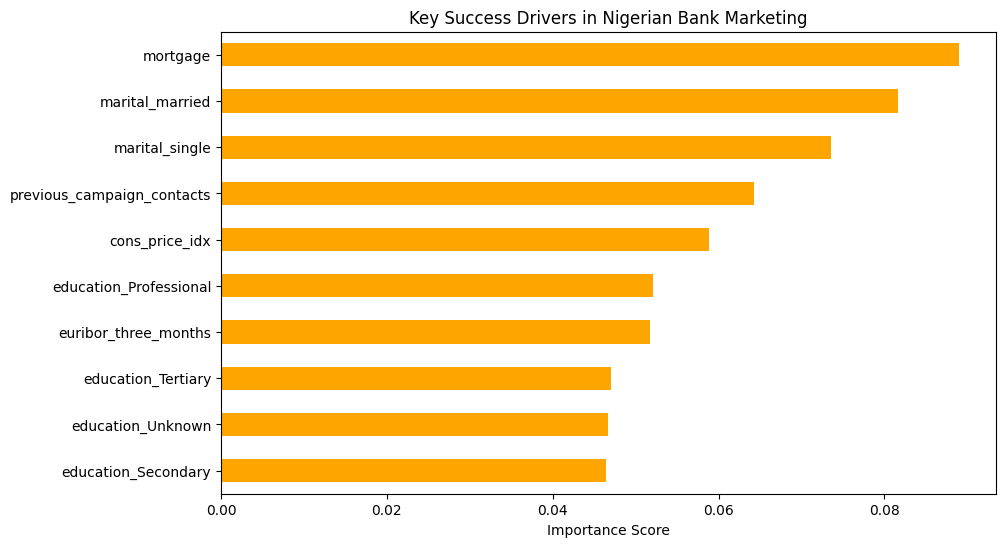

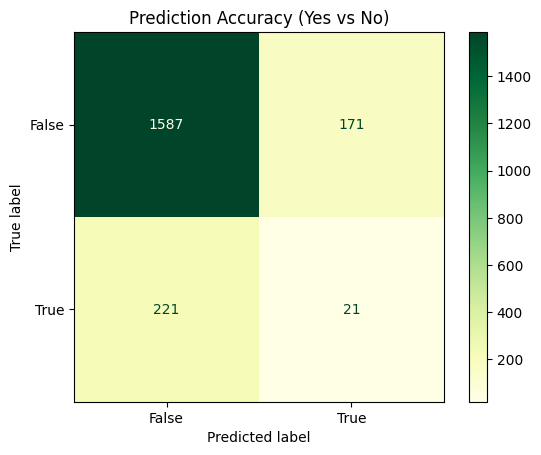

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. GENERATE NIGERIAN SYNTHETIC DATA
# ==========================================
np.random.seed(42)
n_rows = 10000

# Local Nigerian Context
jobs = ['Civil Servant', 'Entrepreneur', 'Trader', 'Artisan', 'Student', 'Corporate Professional', 'Retired', 'Unemployed']
education = ['Primary', 'Secondary', 'Tertiary', 'Professional', 'Unknown']
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

data = {
    'client_id': range(1, n_rows + 1),
    'age': np.random.randint(18, 70, n_rows),
    'job': [np.random.choice(jobs) for _ in range(n_rows)],
    'marital': [np.random.choice(['married', 'single', 'divorced']) for _ in range(n_rows)],
    'education': [np.random.choice(education) for _ in range(n_rows)],
    'credit_default': [np.random.choice(['no', 'no', 'no', 'yes']) for _ in range(n_rows)],
    'mortgage': [np.random.choice(['yes', 'no']) for _ in range(n_rows)],
    'number_contacts': np.random.randint(1, 15, n_rows),
    'month': [np.random.choice(months) for _ in range(n_rows)],
    'day': np.random.randint(1, 31, n_rows),
    'contact_duration': np.random.randint(10, 1200, n_rows), # Seconds
    'previous_campaign_contacts': np.random.randint(0, 5, n_rows),
    'previous_outcome': [np.random.choice(['success', 'failure', 'nonexistent']) for _ in range(n_rows)],
    'cons_price_idx': np.random.uniform(200.0, 350.0, n_rows), # High inflation proxy
    'euribor_three_months': np.random.uniform(15.0, 26.0, n_rows), # Simulating high Nigerian MPR
    'campaign_outcome': [np.random.choice(['yes', 'no'], p=[0.12, 0.88]) for _ in range(n_rows)]
}

marketing = pd.DataFrame(data)
marketing.to_csv("bank_marketing.csv", index=False)
print("✅ Step 1: Nigerian 'bank_marketing.csv' generated.")

# ==========================================
# 2. DATA CLEANING & NORMALIZATION
# ==========================================
# Split into three tables
client = marketing[["client_id", "age", "job", "marital", "education", "credit_default", "mortgage"]].copy()
campaign = marketing[["client_id", "number_contacts", "month", "day", "contact_duration",
                      "previous_campaign_contacts", "previous_outcome", "campaign_outcome"]].copy()
economics = marketing[["client_id", "cons_price_idx", "euribor_three_months"]].copy()

# Cleaning
client["education"] = client["education"].str.replace(".", "_")
for col in ["credit_default", "mortgage"]:
    client[col] = client[col].map({"yes": 1, "no": 0}).fillna(0).astype(bool)

campaign["campaign_outcome"] = campaign["campaign_outcome"].map({"yes": 1, "no": 0}).astype(bool)
campaign["previous_outcome"] = campaign["previous_outcome"].map({"success": 1, "failure": 0, "nonexistent": 0}).astype(bool)

# Build date column
campaign["day"] = campaign["day"].astype(str)
campaign["last_contact_date"] = pd.to_datetime("2026-" + campaign["month"] + "-" + campaign["day"], format="%Y-%b-%d", errors='coerce')
campaign.drop(columns=["month", "day"], inplace=True)
print("✅ Step 2: Data cleaned and split into Client, Campaign, and Economics tables.")

# ==========================================
# 3. SQL STORAGE (Relational Setup)
# ==========================================
conn = sqlite3.connect('nigeria_bank_v2.db')
client.to_sql('clients', conn, if_exists='replace', index=False)
campaign.to_sql('campaigns', conn, if_exists='replace', index=False)
economics.to_sql('economics', conn, if_exists='replace', index=False)
print("✅ Step 3: Relational Database 'nigeria_bank_v2.db' created.")

# ==========================================
# 4. MACHINE LEARNING (Propensity Model)
# ==========================================
# Re-join for modeling
df_model = client.merge(campaign, on="client_id").merge(economics, on="client_id")

# Drop IDs and 'Leakage' features (Duration)
df_model = df_model.drop(columns=['client_id', 'last_contact_date', 'contact_duration'])

# One-Hot Encoding
df_final = pd.get_dummies(df_model, drop_first=True)

# Split and Balance (SMOTE)
X = df_final.drop('campaign_outcome', axis=1)
y = df_final['campaign_outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_res, y_res)

# ==========================================
# 5. VISUALIZING RESULTS
# ==========================================
print("\n--- MODEL SUCCESS REPORT ---")
print(classification_report(y_test, rf.predict(X_test)))

# Feature Importance Plot
plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='orange')
plt.title("Key Success Drivers in Nigerian Bank Marketing")
plt.xlabel("Importance Score")
plt.show()

# Confusion Matrix

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='YlGn')
plt.title("Prediction Accuracy (Yes vs No)")
plt.show()

conn.close()

--- Results at 30.0% Threshold ---
Old Recall (at 50%): 0.09
New Recall (at 30%): 0.50
New Precision: 0.13


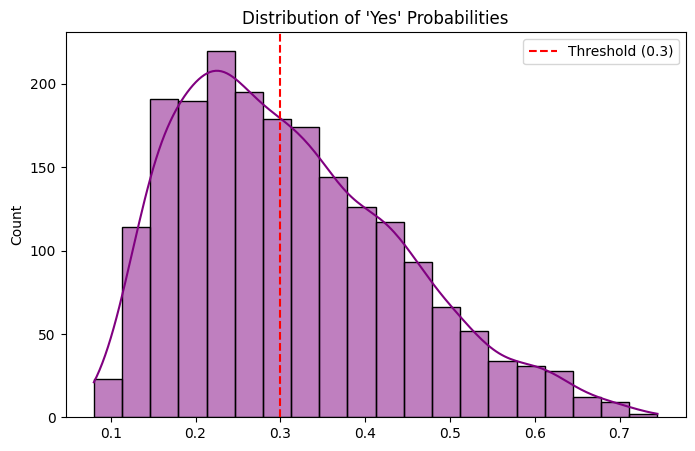

In [3]:
# 1. Get the probabilities instead of the 0/1 predictions
# Column 1 is the probability of a "Yes" (Class 1)
y_probs = rf.predict_proba(X_test)[:, 1]

# Get default predictions for comparison (at 50% threshold)
y_pred = rf.predict(X_test)

# 2. Set a custom threshold (e.g., 0.3 instead of 0.5)
custom_threshold = 0.3
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 3. Compare the "Catch Rate" (Recall)
from sklearn.metrics import recall_score, precision_score

print(f"--- Results at {custom_threshold*100}% Threshold ---")
print(f"Old Recall (at 50%): {recall_score(y_test, y_pred):.2f}")
print(f"New Recall (at 30%): {recall_score(y_test, y_pred_custom):.2f}")
print(f"New Precision: {precision_score(y_test, y_pred_custom):.2f}")

# 4. Plot the Probability Distribution
plt.figure(figsize=(8, 5))
sns.histplot(y_probs, bins=20, kde=True, color='purple')
plt.axvline(custom_threshold, color='red', linestyle='--', label=f'Threshold ({custom_threshold})')
plt.title("Distribution of 'Yes' Probabilities")
plt.legend()
plt.show()


--- MODEL PERFORMANCE (30% THRESHOLD) ---
              precision    recall  f1-score   support

       False       0.88      0.49      0.63      1774
        True       0.11      0.49      0.18       226

    accuracy                           0.49      2000
   macro avg       0.50      0.49      0.41      2000
weighted avg       0.80      0.49      0.58      2000



/tmp/ipython-input-290/4042525617.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='conversion_rate', y='job', data=job_analysis, palette='magma')


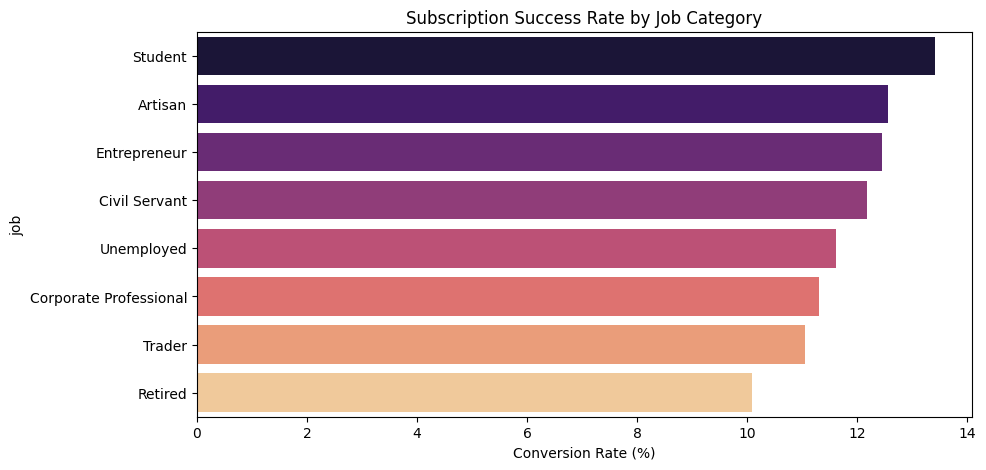

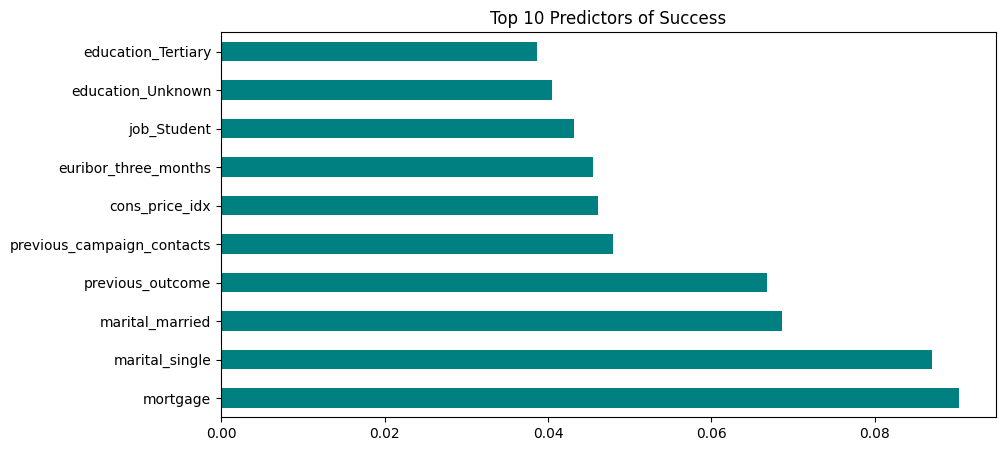

In [5]:
# =================================================================
# 🏦 PROJECT: NIGERIAN RETAIL BANKING PROPENSITY MODEL
# =================================================================
# Install required library for handling imbalanced data
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# -----------------------------------------------------------------
# STEP 1: GENERATE SYNTHETIC NIGERIAN DATA
# -----------------------------------------------------------------
np.random.seed(42)
n_rows = 10000

jobs = ['Civil Servant', 'Entrepreneur', 'Trader', 'Artisan', 'Student', 'Corporate Professional', 'Retired', 'Unemployed']
education = ['Primary', 'Secondary', 'Tertiary', 'Professional', 'Unknown']

data = {
    'client_id': range(1, n_rows + 1),
    'age': np.random.randint(18, 70, n_rows),
    'job': [np.random.choice(jobs) for _ in range(n_rows)],
    'marital': [np.random.choice(['married', 'single', 'divorced']) for _ in range(n_rows)],
    'education': [np.random.choice(education) for _ in range(n_rows)],
    'credit_default': [np.random.choice(['no', 'no', 'no', 'yes']) for _ in range(n_rows)],
    'mortgage': [np.random.choice(['yes', 'no']) for _ in range(n_rows)],
    'number_contacts': np.random.randint(1, 15, n_rows),
    'month': [np.random.choice(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']) for _ in range(n_rows)],
    'day': np.random.randint(1, 28, n_rows),
    'contact_duration': np.random.randint(10, 1200, n_rows),
    'previous_campaign_contacts': np.random.randint(0, 5, n_rows),
    'previous_outcome': [np.random.choice(['success', 'failure', 'nonexistent']) for _ in range(n_rows)],
    'cons_price_idx': np.random.uniform(200.0, 350.0, n_rows), # Inflation Proxy
    'euribor_three_months': np.random.uniform(15.0, 26.0, n_rows), # MPR Proxy
    'campaign_outcome': [np.random.choice(['yes', 'no'], p=[0.12, 0.88]) for _ in range(n_rows)]
}

marketing = pd.DataFrame(data)
marketing.to_csv("bank_marketing.csv", index=False)

# -----------------------------------------------------------------
# STEP 2: DATA CLEANING & SQL NORMALIZATION
# -----------------------------------------------------------------
client = marketing[["client_id", "age", "job", "marital", "education", "credit_default", "mortgage"]].copy()
campaign = marketing[["client_id", "number_contacts", "month", "day", "contact_duration",
                      "previous_campaign_contacts", "previous_outcome", "campaign_outcome"]].copy()
economics = marketing[["client_id", "cons_price_idx", "euribor_three_months"]].copy()

for col in ["credit_default", "mortgage"]:
    client[col] = client[col].map({"yes": 1, "no": 0}).fillna(0).astype(bool)

campaign["campaign_outcome"] = campaign["campaign_outcome"].map({"yes": 1, "no": 0}).astype(bool)
campaign["previous_outcome"] = campaign["previous_outcome"].map({"success": 1, "failure": 0, "nonexistent": 0}).astype(bool)

# Build SQL Database
conn = sqlite3.connect('nigeria_bank_v2.db')
client.to_sql('clients', conn, if_exists='replace', index=False)
campaign.to_sql('campaigns', conn, if_exists='replace', index=False)
economics.to_sql('economics', conn, if_exists='replace', index=False)

# -----------------------------------------------------------------
# STEP 3: MACHINE LEARNING (SMOTE + RANDOM FOREST)
# -----------------------------------------------------------------
df_model = client.merge(campaign, on="client_id").merge(economics, on="client_id")
df_model = df_model.drop(columns=['client_id', 'contact_duration']) # Drop Leakage
df_final = pd.get_dummies(df_model, drop_first=True)

X = df_final.drop('campaign_outcome', axis=1)
y = df_final['campaign_outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_res, y_res)

# -----------------------------------------------------------------
# STEP 4: VISUALIZATION & OUTPUT
# -----------------------------------------------------------------
# 1. Classification Report & Confusion Matrix
y_probs = rf.predict_proba(X_test)[:, 1]
y_pred_30 = (y_probs >= 0.3).astype(int)

print("\n--- MODEL PERFORMANCE (30% THRESHOLD) ---")
print(classification_report(y_test, y_pred_30))

# 2. Conversion by Job Plot
marketing['is_success'] = marketing['campaign_outcome'].map({'yes': 1, 'no': 0})
job_analysis = marketing.groupby('job')['is_success'].mean().sort_values(ascending=False).reset_index()
job_analysis['conversion_rate'] = job_analysis['is_success'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(x='conversion_rate', y='job', data=job_analysis, palette='magma')
plt.title('Subscription Success Rate by Job Category')
plt.xlabel('Conversion Rate (%)')
plt.show()

# 3. Feature Importance Plot
plt.figure(figsize=(10, 5))
pd.Series(rf.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Predictors of Success')
plt.show()

conn.close()